In [1]:
import torch
import numpy as np
from utils.normalizer import Normalizer

# --- paths (use your actual train Y) ---
y_train_path = r"C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version\combined_output_12135_train.npy"

# --- load Y_train ---
Y_train = np.load(y_train_path)              # expect (N_train, 4, 65)
assert Y_train.ndim == 3 and Y_train.shape[1:] == (4, 65), f"got {Y_train.shape}"
Y_train = torch.from_numpy(Y_train).float()

# --- fit & save ---
normalizer = Normalizer()
# If your Normalizer supports fit/transform API:
#Y_train = normalizer.fit_transform(Y_train)  

#normalizer.fit(Y_train)   # same shape (N_train, 4, 65)

save_path = y_train_path.replace(".npy", "_normalizer.pt")
normalizer.fit(Y_train)
normalizer.save(save_path)
print(f"Normalizer saved to: {save_path}")


Normalizer saved to: C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version\combined_output_12135_train_normalizer.pt


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from utils.weighted_loss import WeightedLpLoss 
import numpy as np

from utils.cnn import CNN
from utils.lploss import LpLoss, RMSE
from utils.r2 import r2_np, r2_torch
from utils.normalizer import Normalizer
from utils.log import Logger


# =========================
# Dataset wrapper
# =========================
class npyDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# =========================
# Device + model
# =========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
print(device)
print(model)

# =========================
# Loss, optimizer, scheduler
# =========================
#lploss = LpLoss()
lploss = WeightedLpLoss(weights=[1.0, 1.0, 1.0, 1.0])
mae = nn.L1Loss(reduction='none')

learning_rate = 3e-4
weight_decay = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

batch_size = 32
epochs = 100
scheduler = optim.lr_scheduler.PolynomialLR(optimizer, total_iters=epochs, power=0.9)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#    optimizer,
#    T_max=epochs,
#    eta_min=1e-6
#)
# =========================
# Choose which fold to use
# =========================
fold_id = 0   # <-- change to 1,2,3,4 for other folds

base_dir = r"C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version"

# Files generated by make_kfold_split(...)
train_input_name = fr"{base_dir}\realizations_3dirs_12135_train_fold{fold_id}.npy"
train_gt_name    = fr"{base_dir}\combined_output_12135_train_fold{fold_id}.npy"
val_input_name   = fr"{base_dir}\realizations_3dirs_12135_val_fold{fold_id}.npy"
val_gt_name      = fr"{base_dir}\combined_output_12135_val_fold{fold_id}.npy"

# =========================
# Load arrays for this fold
# =========================
X_train_np = np.load(train_input_name)   # [N_train_fold, 1, 20, 20, 20]
Y_train_np = np.load(train_gt_name)      # [N_train_fold, 4, 65]
X_val_np   = np.load(val_input_name)
Y_val_np   = np.load(val_gt_name)

# Torch datasets
train_dataset = npyDataset(
    torch.tensor(X_train_np, dtype=torch.float32),
    torch.tensor(Y_train_np, dtype=torch.float32),
)
val_dataset = npyDataset(
    torch.tensor(X_val_np, dtype=torch.float32),
    torch.tensor(Y_val_np, dtype=torch.float32),
)

# =========================
# Weighted sampler on qa_peak (this fold only)
# =========================
qa_peak = Y_train_np[:, 2, :].max(axis=1)  # per-sample peak qa

# bins → [ <3k , 3–4k , 4–5k , 5–6k , >6k ]
bins = [3000, 4000, 5000, 6000]
labels = np.digitize(qa_peak, bins=bins, right=False)   # 0,1,2,3,4

# class frequencies
counts = np.bincount(labels, minlength=len(bins)+1).astype(float)
counts[counts == 0] = 1.0  # avoid division by zero
class_w  = 1.0 / counts         # rarer class -> higher weight
class_w[0] *= 0.3   # down-weight low bin
class_w[3] *= 1.5   # up-weight 5000-6000
class_w[4] *= 2.0   # up-weight >6000

sample_w = class_w[labels].astype(np.float32)

# (optional) normalize to mean 1.0
sample_w /= (sample_w.mean() + 1e-12)

weights_tensor = torch.from_numpy(sample_w)
sampler = WeightedRandomSampler(
    weights_tensor,
    num_samples=len(weights_tensor),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,   # sampler → shuffle=False
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train bucket counts (low, mid, high):", counts.tolist())
print("Effective sampling weights used (low, mid, high):", class_w.tolist())

# =========================
# Load shared normalizer (fitted once on BIG train)
# =========================
normalizer = Normalizer()
normalizer.load(fr"{base_dir}\combined_output_12135_train_normalizer.pt")
print("Loaded normalizer from BIG train.")


cuda
CNN(
  (conv1): Conv3d(1, 128, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
  (bn1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv3d(128, 256, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
  (bn2): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv3d(256, 512, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
  (bn3): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv3d(512, 512, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
  (bn4): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv3d(512, 1024, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=(2, 2, 2))
  (bn5): BatchNorm3

In [6]:
import os
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

work_dirs = "./work_dirs"
suffix = "12135"
# ensure the directory exists
os.makedirs(work_dirs, exist_ok=True)

log_path = os.path.join(work_dirs, f"training_log_{suffix}.txt")
logger = Logger(log_path)

print("Logging to:", os.path.abspath(log_path))



for epoch in range(0, epochs):
    
    loss_batch = 0
    loss_epoch = []
    loss_total = []

    feature = ['ps', 'pp', 'qa', 'vol']#['x']#['x','y','z']#

    for i in feature:
        loss_epoch.append(0)
        loss_total.append(0)
    

    ############################################
    # Training
    ############################################

    model.train()

    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        
        inputs = inputs.to(torch.float32).to(device)
        targets = targets.to(torch.float32).to(device)

        outputs = model(inputs)

        outputs = normalizer.inverse_transform(outputs)
        #outputs = normalizer.transform(outputs)
        #targets = normalizer.transform(targets)

        # Loss

        loss = lploss(outputs, targets)
        #loss = mae(outputs, targets)
        #loss = loss.sum(dim=2).mean(dim=0)
        loss_vec = torch.stack(loss)         # tensor[4]
        loss_batch = loss_vec.sum()              # scalar
        # loss = [loss_1, loss_2, ...]
        for i, item in enumerate(loss):
            loss_epoch[i] += item.item()
            #loss_batch += item

        # Backward pass and optimization
        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()

        loss_batch = 0


    # Loss record
    for i, item in enumerate(loss_epoch):
        loss_total[i] = item / len(train_loader)
    
    scheduler.step()

    print(f"epoch: {epoch} - Train Loss: {[round(i,4) for i in loss_total]}")
    logger.log(epoch, "Train", loss_total)
    # print("#"*10)

    ############################################
    # Validation
    ############################################

    loss_batch = 0
    loss_epoch = []
    loss_total = []

    for i in feature:
        loss_epoch.append(0)
        loss_total.append(0)

    model.eval()

    for batch_idx, (inputs, targets) in enumerate(val_loader):
        
        inputs = inputs.to(torch.float32).to(device)
        targets = targets.to(torch.float32).to(device)

        with torch.no_grad():
            outputs = model(inputs)

            outputs = normalizer.inverse_transform(outputs)
            #targets = normalizer.inverse_transform(targets)
            #outputs = normalizer.transform(outputs)
            #targets = normalizer.transform(targets)

        # Loss
        loss = lploss(outputs, targets)
        #loss = mae(outputs, targets)
        #loss = loss.sum(dim=2).mean(dim=0)

        # loss = [loss_1, loss_2, ...]
        for i, item in enumerate(loss):
            loss_epoch[i] += item.item()
            #loss_batch += item


    # Loss record
    for i, item in enumerate(loss_epoch):
        loss_total[i] = item / len(val_loader)
 
    print(f"epoch: {epoch} -   Val Loss: {[round(i,4) for i in loss_total]}")
    print("#"*10)
    logger.log(epoch, "Val", loss_total)
        
    # Fresh epoch loss pool
    loss_epoch = 0


# Save the trained checkpoint
final_ckpt_path = os.path.join(work_dirs, f"epoch_{epoch:03d}_{suffix}.pth")
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optim_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
}, final_ckpt_path)

Logging to: C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version\work_dirs\training_log_12135.txt


C:\Users\xo\AppData\Local\anaconda3\lib\site-packages\torch\nn\modules\conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv3d(


epoch: 0 - Train Loss: [0.0825, 0.0334, 0.1785, 0.3154]
epoch: 0 -   Val Loss: [0.0778, 0.053, 0.2152, 0.4533]
##########
epoch: 1 - Train Loss: [0.0622, 0.0306, 0.2393, 0.2785]
epoch: 1 -   Val Loss: [0.0697, 0.0532, 0.2201, 0.4227]
##########
epoch: 2 - Train Loss: [0.059, 0.0308, 0.1632, 0.2778]
epoch: 2 -   Val Loss: [0.074, 0.0515, 0.2006, 0.4517]
##########
epoch: 3 - Train Loss: [0.0561, 0.0306, 0.1576, 0.2684]
epoch: 3 -   Val Loss: [0.0759, 0.0539, 0.2297, 0.4814]
##########
epoch: 4 - Train Loss: [0.0566, 0.03, 0.2332, 0.2776]
epoch: 4 -   Val Loss: [0.0748, 0.0523, 0.1912, 0.4174]
##########
epoch: 5 - Train Loss: [0.056, 0.0305, 0.1614, 0.2714]
epoch: 5 -   Val Loss: [0.0659, 0.0542, 0.2006, 0.4038]
##########
epoch: 6 - Train Loss: [0.0555, 0.0302, 0.1589, 0.2695]
epoch: 6 -   Val Loss: [0.0723, 0.0523, 0.1985, 0.3882]
##########
epoch: 7 - Train Loss: [0.0563, 0.0303, 0.2361, 0.2727]
epoch: 7 -   Val Loss: [0.0932, 0.0544, 0.2095, 0.4113]
##########
epoch: 8 - Train Loss:

epoch: 66 -   Val Loss: [0.0749, 0.0506, 0.2044, 0.4173]
##########
epoch: 67 - Train Loss: [0.05, 0.0284, 0.1446, 0.2355]
epoch: 67 -   Val Loss: [0.0818, 0.0517, 0.2197, 0.4279]
##########
epoch: 68 - Train Loss: [0.0496, 0.0284, 0.1437, 0.2359]
epoch: 68 -   Val Loss: [0.0696, 0.0518, 0.1978, 0.4063]
##########
epoch: 69 - Train Loss: [0.049, 0.0278, 0.1994, 0.2319]
epoch: 69 -   Val Loss: [0.0778, 0.0529, 0.2185, 0.4234]
##########
epoch: 70 - Train Loss: [0.0496, 0.0281, 0.1432, 0.2359]
epoch: 70 -   Val Loss: [0.0685, 0.0521, 0.2091, 0.392]
##########
epoch: 71 - Train Loss: [0.0485, 0.028, 0.1398, 0.2255]
epoch: 71 -   Val Loss: [0.0823, 0.0519, 0.2374, 0.5131]
##########
epoch: 72 - Train Loss: [0.0484, 0.0277, 0.1416, 0.2319]
epoch: 72 -   Val Loss: [0.0753, 0.0507, 0.2259, 0.4827]
##########
epoch: 73 - Train Loss: [0.0485, 0.0276, 0.1414, 0.2313]
epoch: 73 -   Val Loss: [0.075, 0.0516, 0.2035, 0.3798]
##########
epoch: 74 - Train Loss: [0.0494, 0.0286, 0.272, 0.2338]
epoch: 

import os
import torch

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

work_dirs = "./work_dirs"
suffix = "11835"
os.makedirs(work_dirs, exist_ok=True)

log_path = os.path.join(work_dirs, f"training_log_{suffix}.txt")
logger = Logger(log_path)

print("Logging to:", os.path.abspath(log_path))

# ==== Early stopping settings ====
best_val = float('inf')
patience = 10
no_improve = 0
best_ckpt_path = os.path.join(work_dirs, f"best_epoch_{suffix}.pth")


for epoch in range(epochs):

    # -----------------------------
    # TRAINING LOOP
    # -----------------------------
    loss_epoch = [0,0,0,0]   # per-feature loss
    model.train()

    for batch_idx, (inputs, targets) in enumerate(train_loader):

        inputs  = inputs.to(torch.float32).to(device)
        targets = targets.to(torch.float32).to(device)

        outputs = model(inputs)

        outputs = normalizer.transform(outputs)
        targets = normalizer.transform(targets)

        # ---- Compute weighted multi-channel loss ----
        loss_list = lploss(outputs, targets)        # list of 4 tensors
        loss_vec  = torch.stack(loss_list)          # torch.Size([4])
        loss_batch = loss_vec.sum()                 # scalar

        # ---- accumulate per-channel losses for printing ----
        for i, item in enumerate(loss_list):
            loss_epoch[i] += item.item()

        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()

    # ---- average per-feature loss ----
    train_loss_avg = [x / len(train_loader) for x in loss_epoch]

    scheduler.step()
    print(f"epoch: {epoch} - Train Loss: {[round(i,4) for i in train_loss_avg]}")
    logger.log(epoch, "Train", train_loss_avg)

    # -----------------------------
    # VALIDATION LOOP
    # -----------------------------
    loss_epoch = [0,0,0,0]
    model.eval()

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):

            inputs  = inputs.to(torch.float32).to(device)
            targets = targets.to(torch.float32).to(device)

            outputs = model(inputs)
            outputs = normalizer.transform(outputs)
            targets = normalizer.transform(targets)

            loss_list = lploss(outputs, targets)

            for i, item in enumerate(loss_list):
                loss_epoch[i] += item.item()

    val_loss_avg = [x / len(val_loader) for x in loss_epoch]

    print(f"epoch: {epoch} -   Val Loss: {[round(i,4) for i in val_loss_avg]}")
    print("#" * 10)
    logger.log(epoch, "Val", val_loss_avg)

    # -----------------------------
    # EARLY STOPPING
    # Use mean of QA + VOL because they are your hardest features
    # -----------------------------
    val_monitor = (val_loss_avg[2] + val_loss_avg[3]) / 2.0

    if val_monitor < best_val:
        best_val = val_monitor
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optim_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
        }, best_ckpt_path)
        print(f" New best model saved at epoch {epoch} (monitor={best_val:.4f})")

    else:
        no_improve += 1
        print(f"  No improve for {no_improve} epochs")

        if no_improve >= patience:
            print(f" EARLY STOP at epoch {epoch}, best monitor={best_val:.4f}")
            break

# ---- also save final checkpoint ----
final_ckpt_path = os.path.join(work_dirs, f"epoch_{epoch:03d}_{suffix}.pth")
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optim_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
}, final_ckpt_path)

print(f"Final checkpoint saved: {final_ckpt_path}")
print(f"Best checkpoint saved:  {best_ckpt_path}")


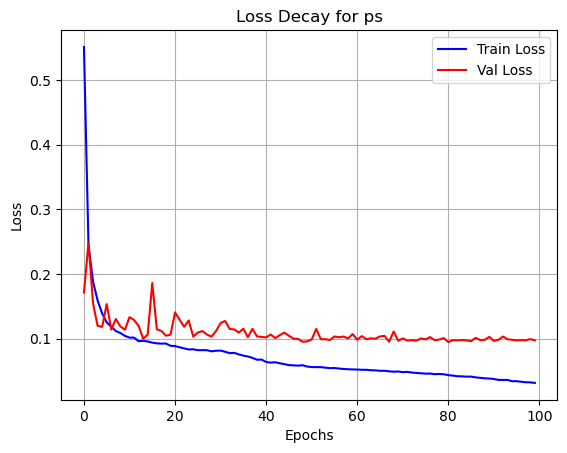

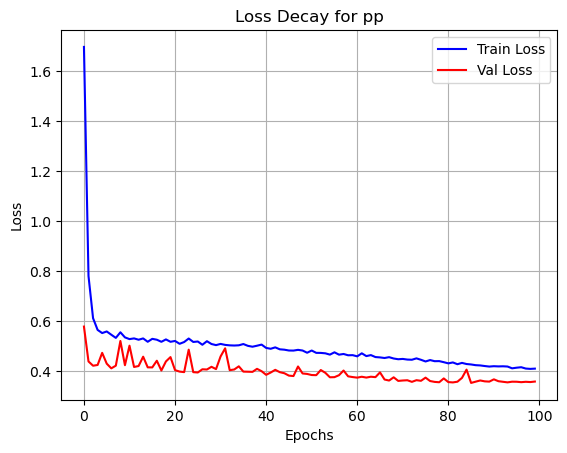

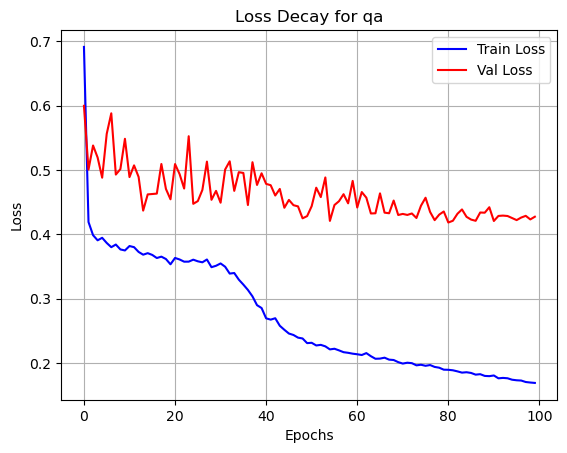

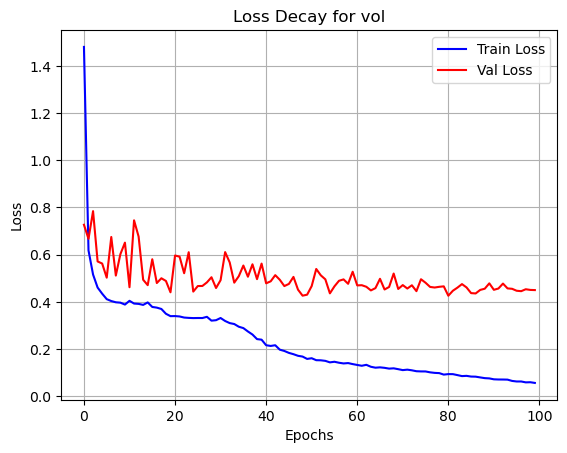

In [8]:
import matplotlib.pyplot as plt

# Function to read losses from the .txt file
def read_losses_from_file(file_path):
    train_losses = []
    val_losses = []

    with open(file_path, 'r') as f:
        for line in f:
            if "Train Loss" in line:
                # Extract the losses between the square brackets
                losses = line.split('[')[1].split(']')[0].split(',')
                train_losses.append([float(l.strip()) for l in losses])
            elif "Val Loss" in line:
                # Extract the losses between the square brackets
                losses = line.split('[')[1].split(']')[0].split(',')
                val_losses.append([float(l.strip()) for l in losses])

    return train_losses, val_losses

# Function to plot the loss decay
def plot_loss_decay(train_losses, val_losses, feature_names):
    epochs = range(len(train_losses))

    # Plot for each feature separately
    for i, feature_name in enumerate(feature_names):
        plt.figure()
        train_loss_feature = [epoch_loss[i] for epoch_loss in train_losses]
        val_loss_feature = [epoch_loss[i] for epoch_loss in val_losses]

        # Plot train loss
        plt.plot(epochs, train_loss_feature, label='Train Loss', color='blue')

        # Plot validation loss
        plt.plot(epochs, val_loss_feature, label='Val Loss', color='red')

        plt.title(f'Loss Decay for {feature_name}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

file_path = './work_dirs_12135/training_log_12135.txt'


# Feature names corresponding to the losses
feature_names = ['ps', 'pp', 'qa', 'vol']

# Read losses from file
train_losses, val_losses = read_losses_from_file(file_path)

# Plot the loss decay
plot_loss_decay(train_losses, val_losses, feature_names)

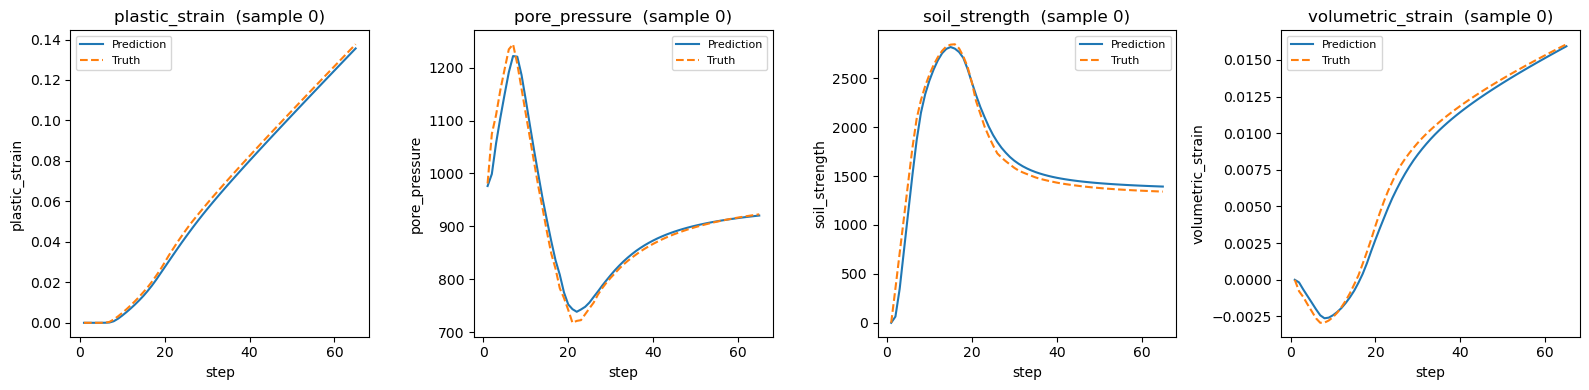

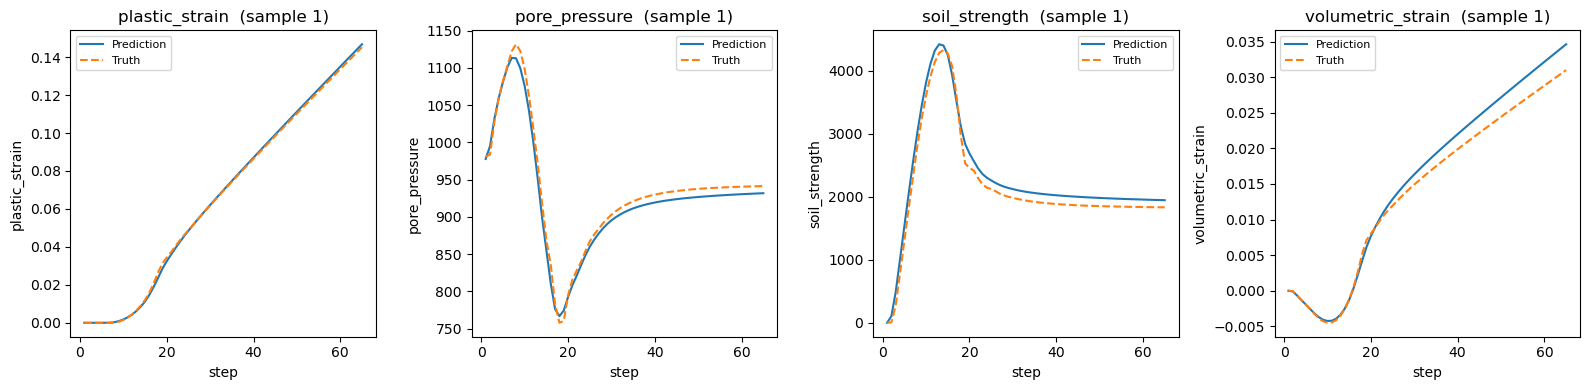

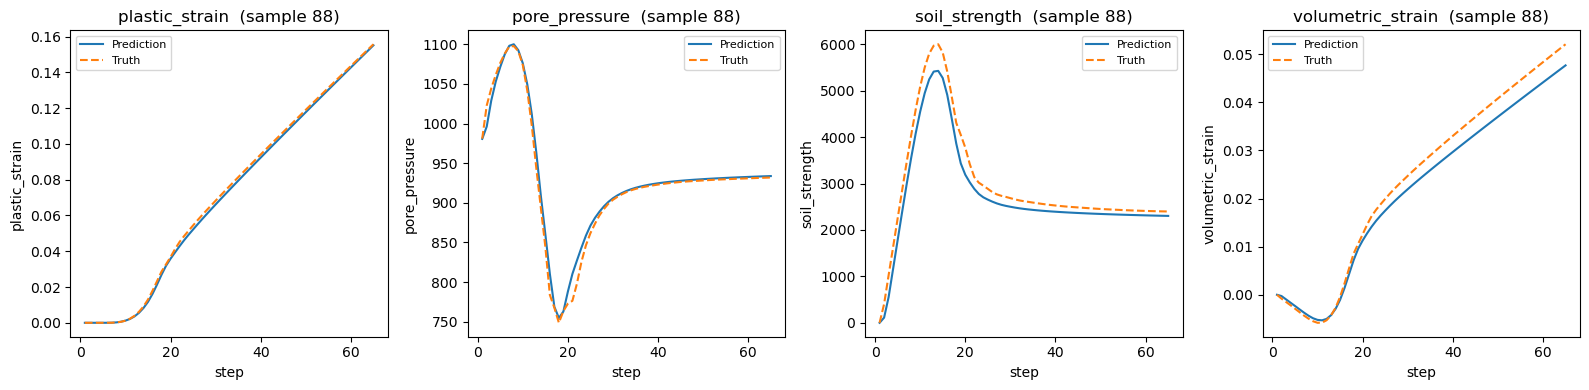

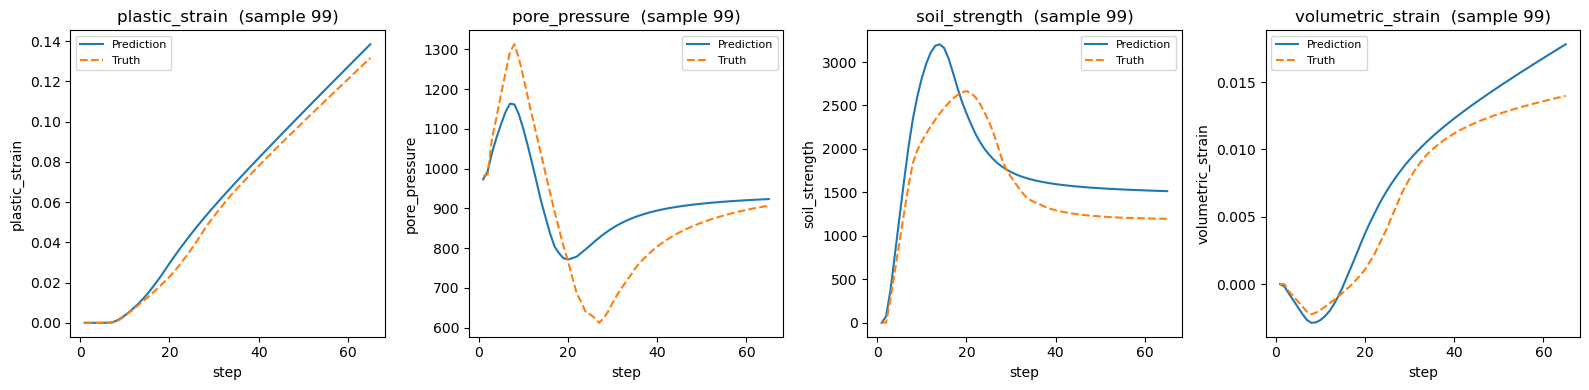

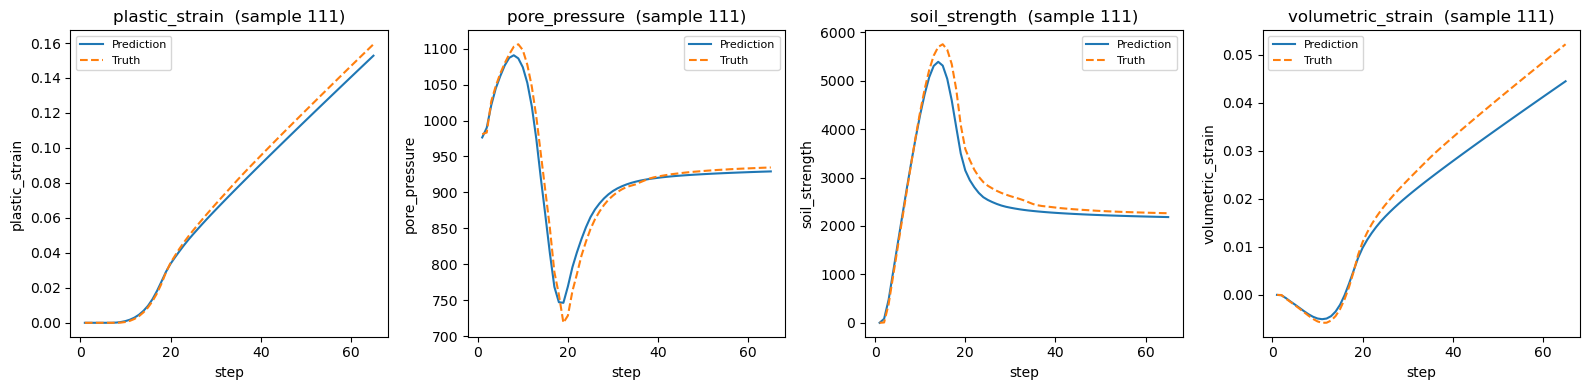

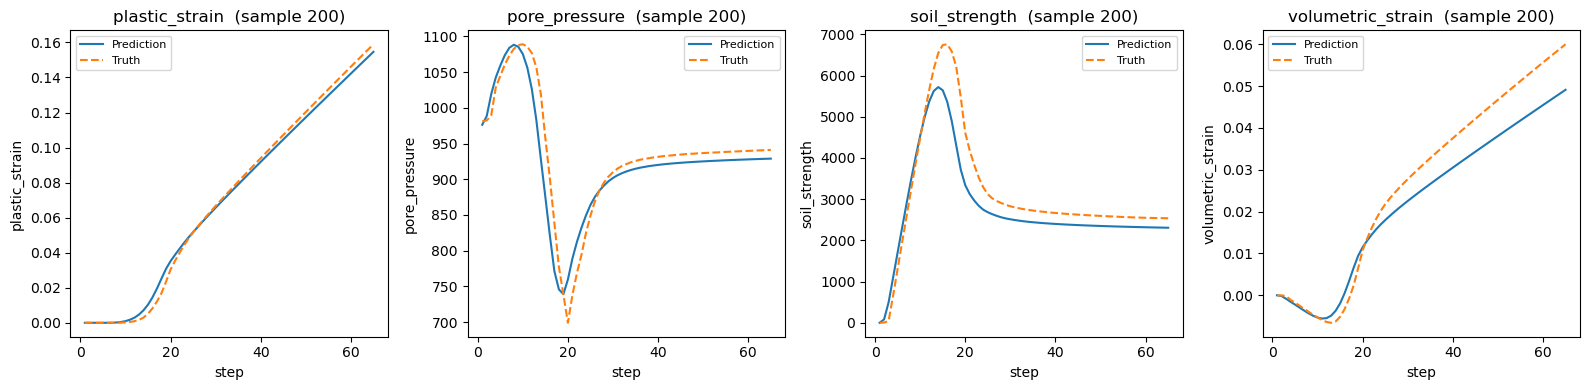

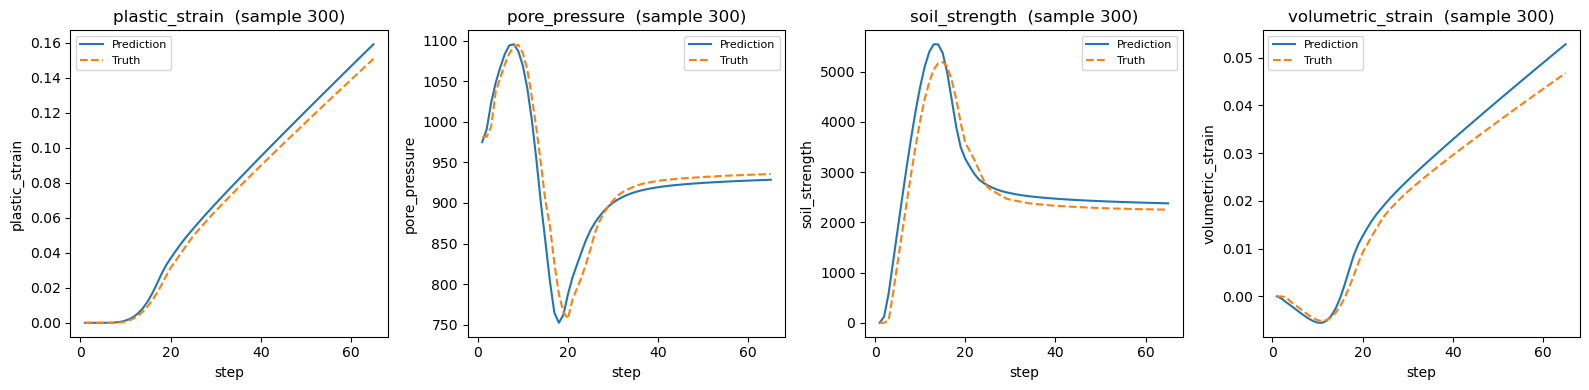

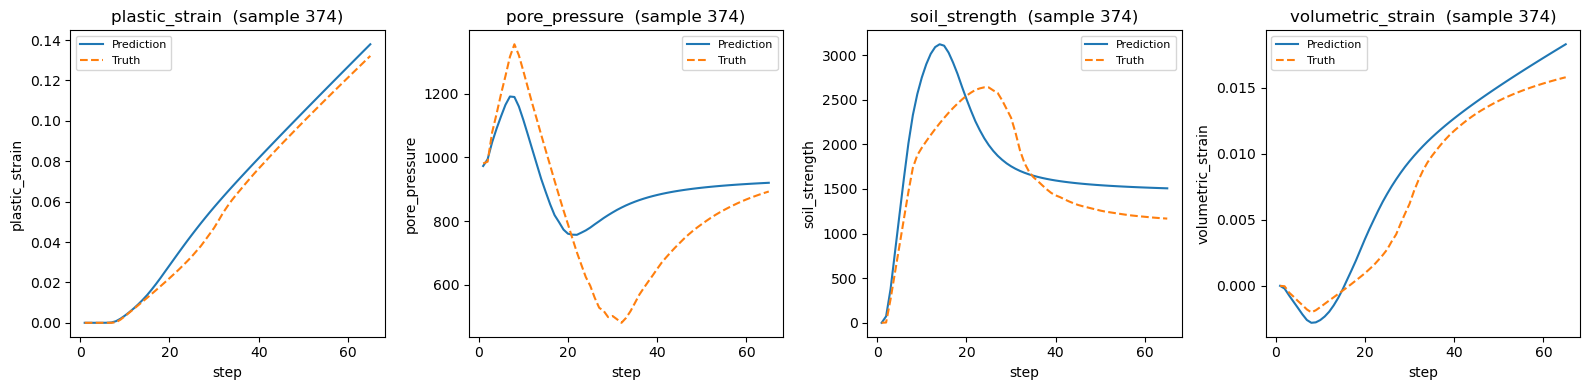

In [6]:
import torch, numpy as np, matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# Choose which dataset you’re indexing:
# If you want large indices like 3000/6145/9290, load the FULL arrays (not the val split).
X = np.load('realizations_3dirs_12135_test.npy')     # shape [N, ...]
Y = np.load('combined_output_12135_test.npy')             # shape [N, 4, 65]

idx_list = [0, 1, 88, 99, 111, 200, 300, 374]               # samples you want (global indices)
labels = ['plastic_strain', 'pore_pressure', 'soil_strength', 'volumetric_strain']
axial = np.arange(1, Y.shape[-1] + 1)          # should be 65

for s in idx_list:
    if not (0 <= s < X.shape[0]):
        print(f"Skip {s}: out of range for this file (N={X.shape[0]})")
        continue

    # batch of size 1 for this sample
    data  = torch.tensor(X[s:s+1], dtype=torch.float32).to(device)      # [1, ...]
    truth = torch.tensor(Y[s:s+1], dtype=torch.float32).cpu().numpy()   # [1, 4, 65]

    with torch.no_grad():
        pred = model(data).cpu()                                        # [1, 4, 65]


    # --- one figure per sample: 4 subplots ---
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    for c, ax in enumerate(axs):
        ax.plot(axial, pred[0, c].ravel(),          label='Prediction')
        ax.plot(axial, truth[0, c].ravel(), '--',   label='Truth')
        ax.set_title(f'{labels[c]}  (sample {s})')
        ax.set_xlabel('step'); ax.set_ylabel(labels[c])
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


Found 12135 candidate files under:
  C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version\soil strength input
✅ Loaded peaks from 12135 files.
⚠️  Skipped 0 files.


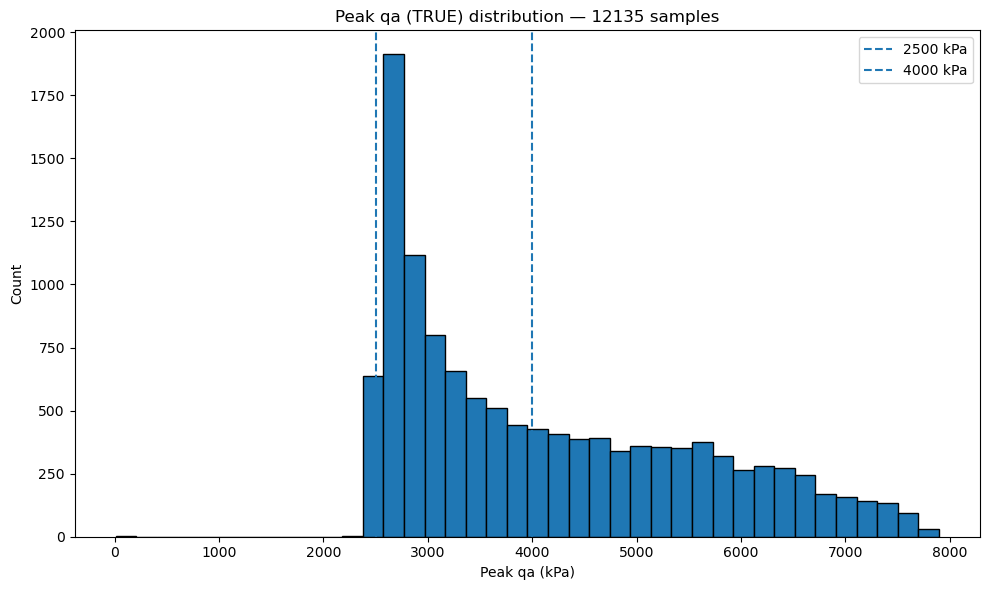

Saved qa_peaks_true_from_folder.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# -----------------------------
# USER SETTINGS
# -----------------------------
soil_strength_dir = Path(r"C:\Users\xo\CNN_3D_python\20251118_final 3dcnn version\soil strength input")

LOW_THR  = 2500
HIGH_THR = 4000

# If you ONLY want files that contain qa in the name, keep this:
NAME_MUST_CONTAIN = "qa"   # set to None if you want to read every file

# -----------------------------
# Helper: robust 2-column reader
# -----------------------------
def read_two_cols(filepath: Path) -> np.ndarray:
    """
    Returns Nx2 float array: col0=axial strain, col1=qa
    Handles: headers/no headers, commas/tabs/spaces
    """
    # Try common separators first
    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(
                filepath,
                header=None,
                sep=sep,
                engine="python",
                comment="#"
            )
            # keep only numeric-ish cols
            if df.shape[1] >= 2:
                # take first two columns
                arr = df.iloc[:, :2].apply(pd.to_numeric, errors="coerce").to_numpy()
                # drop rows where qa is NaN
                arr = arr[~np.isnan(arr[:, 1])]
                if arr.shape[0] > 0:
                    return arr
        except Exception:
            pass

    # Fallback: let pandas guess (more expensive)
    df = pd.read_csv(filepath, sep=None, engine="python", comment="#", header=None)
    if df.shape[1] < 2:
        raise ValueError(f"File has <2 columns: {filepath.name}")
    arr = df.iloc[:, :2].apply(pd.to_numeric, errors="coerce").to_numpy()
    arr = arr[~np.isnan(arr[:, 1])]
    if arr.shape[0] == 0:
        raise ValueError(f"No numeric qa values in: {filepath.name}")
    return arr

# -----------------------------
# Collect peak qa from folder
# -----------------------------
all_files = []
for ext in ("*.csv", "*.tab", "*.txt", "*.dat"):
    all_files.extend(soil_strength_dir.rglob(ext))

if NAME_MUST_CONTAIN is not None:
    all_files = [p for p in all_files if NAME_MUST_CONTAIN.lower() in p.name.lower()]

print(f"Found {len(all_files)} candidate files under:\n  {soil_strength_dir}")

peaks = []
bad = []

for p in all_files:
    try:
        data = read_two_cols(p)  # [:,0]=axial strain, [:,1]=qa
        qa = data[:, 1]
        peaks.append(float(np.nanmax(qa)))
    except Exception as e:
        bad.append((p.name, str(e)))

print(f"✅ Loaded peaks from {len(peaks)} files.")
print(f"⚠️  Skipped {len(bad)} files.")

# If you expect EXACTLY 12135 and want a warning:
if len(peaks) != 12135:
    print(f"NOTE: expected 12135, got {len(peaks)}. "
          f"(This is usually filename filtering or missing files.)")

# -----------------------------
# Plot histogram (same style as your 375 plot)
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(peaks, bins=40, edgecolor="black")
plt.axvline(LOW_THR, linestyle="--", label=f"{LOW_THR} kPa")
plt.axvline(HIGH_THR, linestyle="--", label=f"{HIGH_THR} kPa")
plt.title(f"Peak qa (TRUE) distribution — {len(peaks)} samples")
plt.xlabel("Peak qa (kPa)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# (Optional) Save peaks so you never have to re-scan files again
pd.DataFrame({"qa_peak_true": peaks}).to_csv("qa_peaks_true_from_folder.csv", index=False)
print("Saved qa_peaks_true_from_folder.csv")
